<br/>

<div align="center">
<span style="font-size: 2.5em;">Neural vs Analytical Posterior</span>
<br/>
<span style="font-size: 1.2em; color: gray;">(Binned Data)</span>
</div>

We compare analytical Poisson posteriors against neural-network posteriors using binned observables. The analytical result serves as a reference to assess calibration, sharpness, and possible biases in the NN outputs.

In [ ]:
import os
desired_root_name = "xenon-sbi" 
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

import torch

from data.mc_generator import mc_generator
from data.generate_dataset import generate_features
from analytical.ppg_class import PoissonPosteriorGrid
from configs.config import MCConfig, load_model
from utils.posteriors import plot_posteriors_comparison, posterior_grid
from utils.processing import preprocess_features, make_dataloaders, make_negative_pairs


In [2]:
# --------------------- SELECT MODEL TO LOAD ---------------------

modelname = "ntothighest"          
halo      = "default"       
datatag   = "low"
n_train   = 300_000

bins = MCConfig().bins     
top_k     = 10                

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------- PATHS ---------------------

DATAPATH = f"data/datasets/wimpy/{halo}/wimpy_n{n_train}_{datatag}_{halo}.pt"
MODELPATH = f"models/wimpy/{halo}/{modelname}_n{n_train}_{datatag}_{halo}.pt"
print(f"Loading model from:\n{MODELPATH}\n")

# --------------------- LOAD MODEL ---------------------
model, _ = load_model(MODELPATH, modelname, bins, top_k, device, print_arch=True)

Loading model from:
models/wimpy/default/ntothighest_n300000_low_default.pt

Ntot_Highest_MLP(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.05, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): SiLU()
    (7): Dropout(p=0.05, inplace=False)
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): SiLU()
    (11): Dropout(p=0.05, inplace=False)
    (12): Linear(in_features=512, out_features=512, bias=True)
    (13): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): SiLU()
    (15): Dropout(p=0.05, inplace=False)
    (16): Linear(in_features=512, out_features=

In [3]:
# ------------- LOAD DATA ----------------

data = torch.load(DATAPATH, weights_only=False)

theta_tensor = data["theta"]
feature_tensor = data["features"]
logm_range  = data['logm_range']
logcp_range = data['logcp_range']
mc_cfg      = MCConfig()

feature_tensor = preprocess_features(model, feature_tensor, device)
X_all, T_all, Y_all = make_negative_pairs(feature_tensor, theta_tensor)

_, val_loader, _ = make_dataloaders(X_all, T_all, Y_all)

<br/>

<div align="center">
<span style="font-size: 1.5em;"> Single Comparison (One Mock Observation) </span>

</div>

In [4]:
def plot_comparison(mchi_true, cp_true, save_path=None):
    
    # Generate observation + split for methods
    counts, _ = generate_features(mchi_true, cp_true, top_k=top_k, **mc_cfg.__dict__)
    n_mock = int(counts[bins])
    counts_ana = counts[:bins]
    x_nn = preprocess_features(model, counts, device)

    # Analytical
    ppg = PoissonPosteriorGrid.load_or_compute("low", 200, mc_generator)
    post_ana = ppg.posterior_binned(counts_ana)
    m_an, cp_an = 10**ppg.logm_vals, 10**ppg.logcp_vals

    # Neural
    post_nn, lm_nn, lc_nn = posterior_grid(x_nn, logm_range, logcp_range, 200, model, device)
    m_nn, cp_nn = 10**lm_nn, 10**lc_nn

    # Compare
    plot_posteriors_comparison(
        mchi_true,
        cp_true,
        post_ana,
        m_an,
        cp_an,
        post_nn,
        m_nn,
        cp_nn,
        n_mock,
        save_path=save_path,
    )
    print(f"Saved: {save_path}")

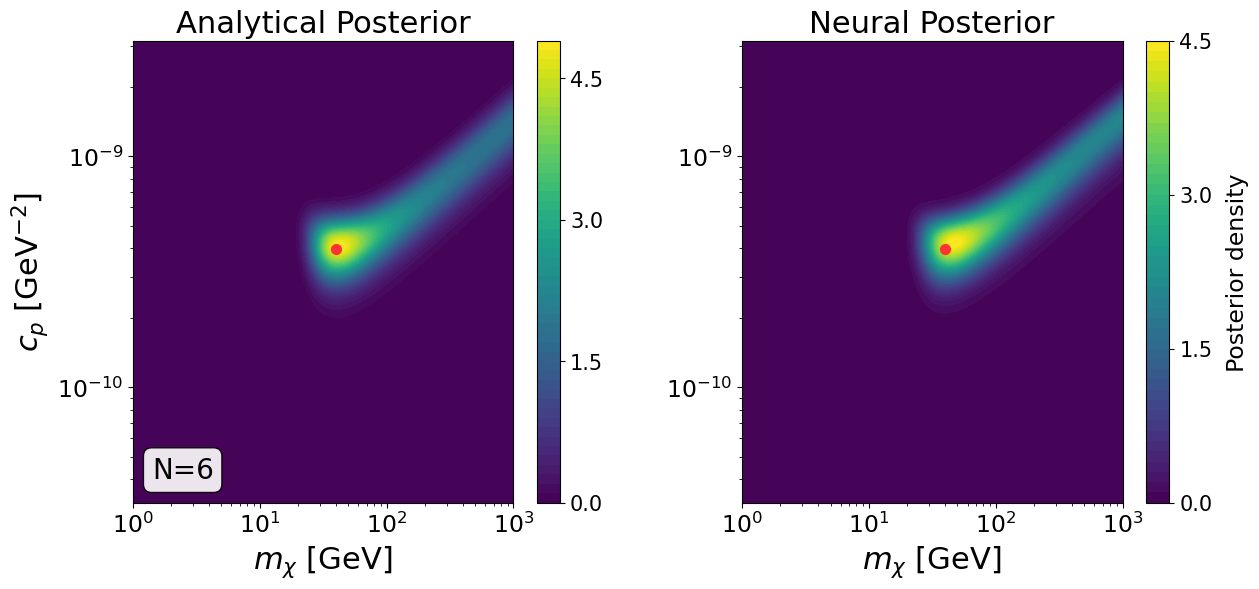

Saved: figures/chap6/ntothighest_default_low_analytical_posterior_comparison.pdf


In [8]:
plot_comparison(mchi_true=40, cp_true=10**(-9.4), save_path=f"figures/chap6/{modelname}_{halo}_{datatag}_analytical_posterior_comparison.pdf")

<br/>

<div align="center">
<span style="font-size: 1.5em;"> Multiple Comparisons (Grid of Truths) </span>

</div>

In [6]:
if 0: 
    mchi_vals = [10, 30, 100, 500]
    cp_vals   = [10**(-10), 10**(-9.5), 10**(-9), 10**(-8.8)]

    for m in mchi_vals:
        for cp in cp_vals:
            print(f"\n=== Running comparison for mχ={m}, cp={cp:.2g} ===")
            plot_comparison(mchi_true=m, cp_true=cp)